In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# 한글 폰트 및 마이너스 기호 설정 (Windows)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

# 1. 삼성전자(005930.KS) 데이터 수집 (2023-01-01 ~ 2024-12-31)
df = yf.download('005930.KS', start='2023-01-01', end='2024-12-31')

# CSV 파일로 저장
df.to_csv('data/samsung_stock.csv')

print(f"전체 데이터 개수: {len(df)}개")
df.head()

[*********************100%***********************]  1 of 1 completed

전체 데이터 개수: 489개


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2023-01-02,51925.339844,52486.694869,51644.662331,51925.339844,10031448
2023-01-03,51831.785156,52393.140230,50989.752545,51831.785156,13547030
2023-01-04,54077.203125,54264.321475,52018.901276,52112.460451,20188071
2023-01-05,54451.437500,55012.792526,53890.082474,54451.437500,15682826
2023-01-06,55199.910156,55574.146835,54170.759289,54544.995968,17334989


In [2]:
# 1. 데이터 구조 단순화 (MultiIndex 정리)
if isinstance(df.columns, pd.MultiIndex):
    df_clean = df['Close'].copy()
else:
    df_clean = df[['Close']].copy()

df_clean.columns = ['Close']

# 2. 결측치 확인 및 처리 (앞의 값으로 채우기)
print("결측치 개수:", df_clean.isnull().sum().sum())
df_clean = df_clean.ffill()

# 3. [시계열 분석 기법 1] 이동평균선(Moving Average) 계산 (20일, 60일)
df_clean['MA20'] = df_clean['Close'].rolling(window=20).mean()
df_clean['MA60'] = df_clean['Close'].rolling(window=60).mean()

# 4. [시계열 분석 기법 2] 일간 수익률/변화율(Daily Return, %) 계산
df_clean['Daily_Return'] = df_clean['Close'].pct_change() * 100

# 5. [시계열 분석 기법 3] 변동성 (20일 이동 표준편차)
df_clean['Volatility20'] = df_clean['Daily_Return'].rolling(window=20).std()

print("\n--- 전처리 및 시계열 분석 변수 추가 완료 ---")
df_clean.tail(10)

결측치 개수: 0

--- 전처리 및 시계열 분석 변수 추가 완료 ---


,Close,MA20,MA60,Daily_Return,Volatility20
Date,,,,,
2024-12-16,53886.394531,53464.805664,55808.386914,-0.891266,1.768190
2024-12-17,52529.542969,53363.041406,55670.312240,-2.517985,1.846483
2024-12-18,53207.972656,53343.657617,55545.150911,1.291520,1.833733
2024-12-19,51463.449219,53183.742773,55397.339388,-3.278688,1.906777
2024-12-20,51366.531250,53038.365820,55238.274870,-0.188324,1.904215
2024-12-23,51851.121094,52825.146289,55103.349674,0.943396,1.727651
2024-12-24,52723.382812,52636.156250,54942.805013,1.682243,1.773609
2024-12-26,51948.035156,52505.316602,54771.583203,-1.470595,1.642624
2024-12-27,52399.828125,52435.833789,54651.504362,0.869702,1.635247


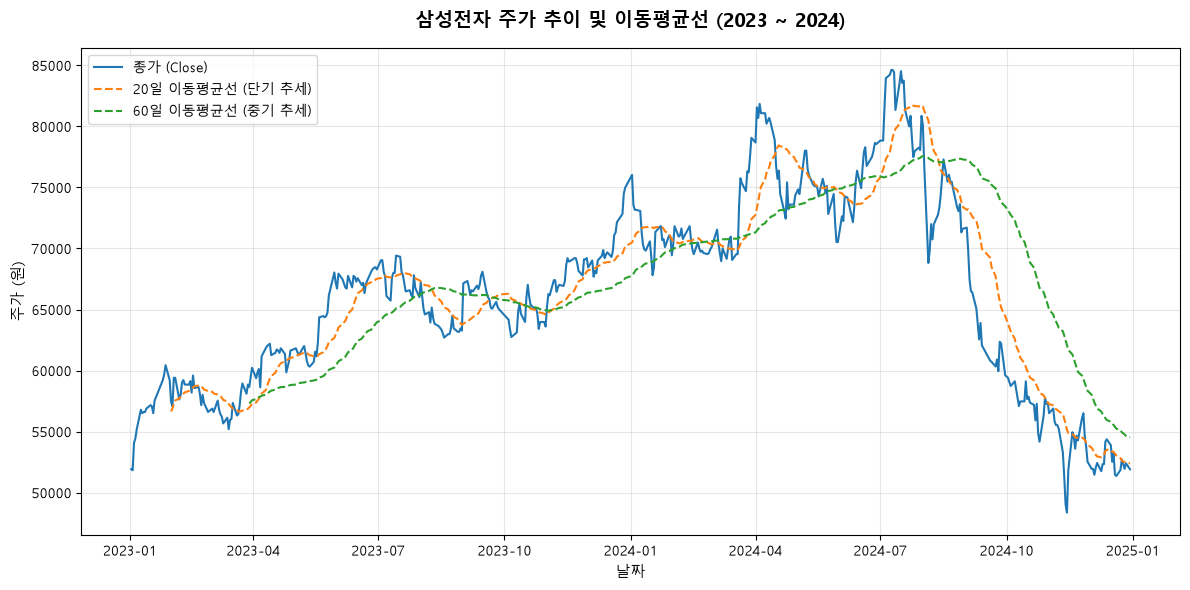

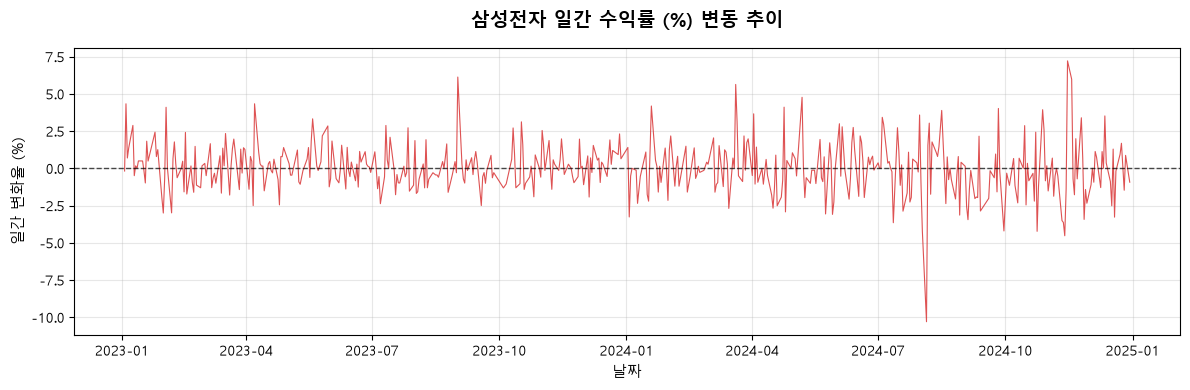

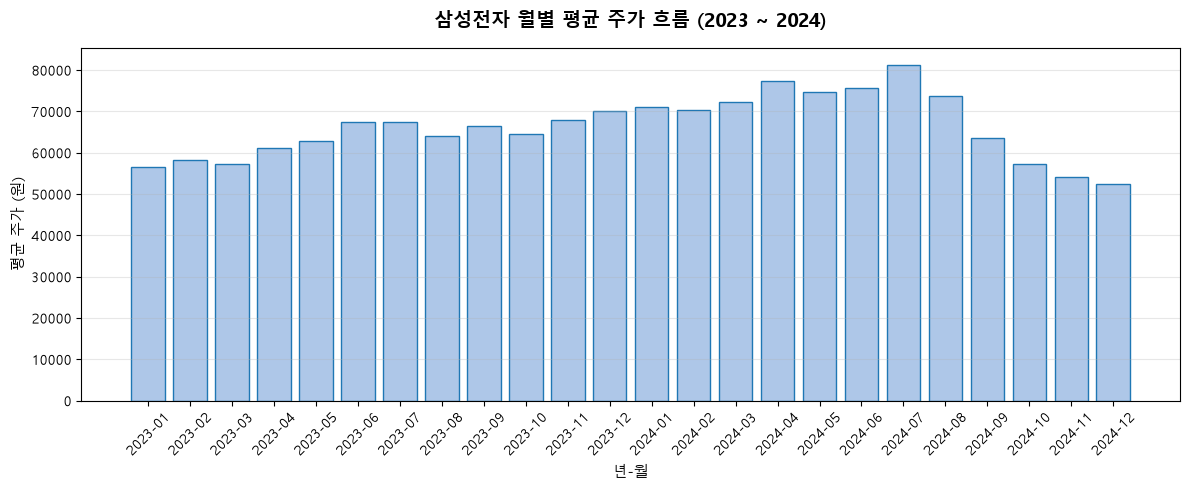

In [3]:
import os
os.makedirs('images', exist_ok=True) # images 폴더가 없으면 자동 생성

# [시각화 1] 주가 추이 및 이동평균선 (20일 / 60일)
plt.figure(figsize=(12, 6))
plt.plot(df_clean.index, df_clean['Close'], label='종가 (Close)', color='#1f77b4', linewidth=1.5)
plt.plot(df_clean.index, df_clean['MA20'], label='20일 이동평균선 (단기 추세)', color='#ff7f0e', linestyle='--')
plt.plot(df_clean.index, df_clean['MA60'], label='60일 이동평균선 (중기 추세)', color='#2ca02c', linestyle='--')
plt.title('삼성전자 주가 추이 및 이동평균선 (2023 ~ 2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('날짜', fontsize=11)
plt.ylabel('주가 (원)', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/01_price_trend.png', dpi=300)
plt.show()

# [시각화 2] 일간 변화율(수익률 %) 추이
plt.figure(figsize=(12, 4))
plt.plot(df_clean.index, df_clean['Daily_Return'], color='#d62728', linewidth=0.8, alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title('삼성전자 일간 수익률 (%) 변동 추이', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('날짜', fontsize=11)
plt.ylabel('일간 변화율 (%)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/02_daily_return.png', dpi=300)
plt.show()

# [시각화 3] 월별 평균 주가 패턴
df_monthly = df_clean['Close'].resample('ME').mean()
plt.figure(figsize=(12, 5))
bars = plt.bar(df_monthly.index.strftime('%Y-%m'), df_monthly.values, color='#aec7e8', edgecolor='#1f77b4')
plt.title('삼성전자 월별 평균 주가 흐름 (2023 ~ 2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('년-월', fontsize=11)
plt.ylabel('평균 주가 (원)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/03_monthly_avg.png', dpi=300)
plt.show()

In [5]:
!pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.3 MB 5.6 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 6.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 6.7 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.3 MB 6.8 MB/s eta 0:00:01
   ----------------------- ---------------- 6.6/11.3 MB 6.2 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.3 MB 6.3 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.3 MB 6.4 MB/s eta 0:00:01
   -------------------------------------- - 11.0/11.3 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 6.5 MB/s  0:00:01
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.4 MB 6.9 MB/s eta 0:00:06
   --- ------------------------------------ 3.4/37.4 MB 8.1 MB/s eta 0:00:05
   ----- -----


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\elsa5\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


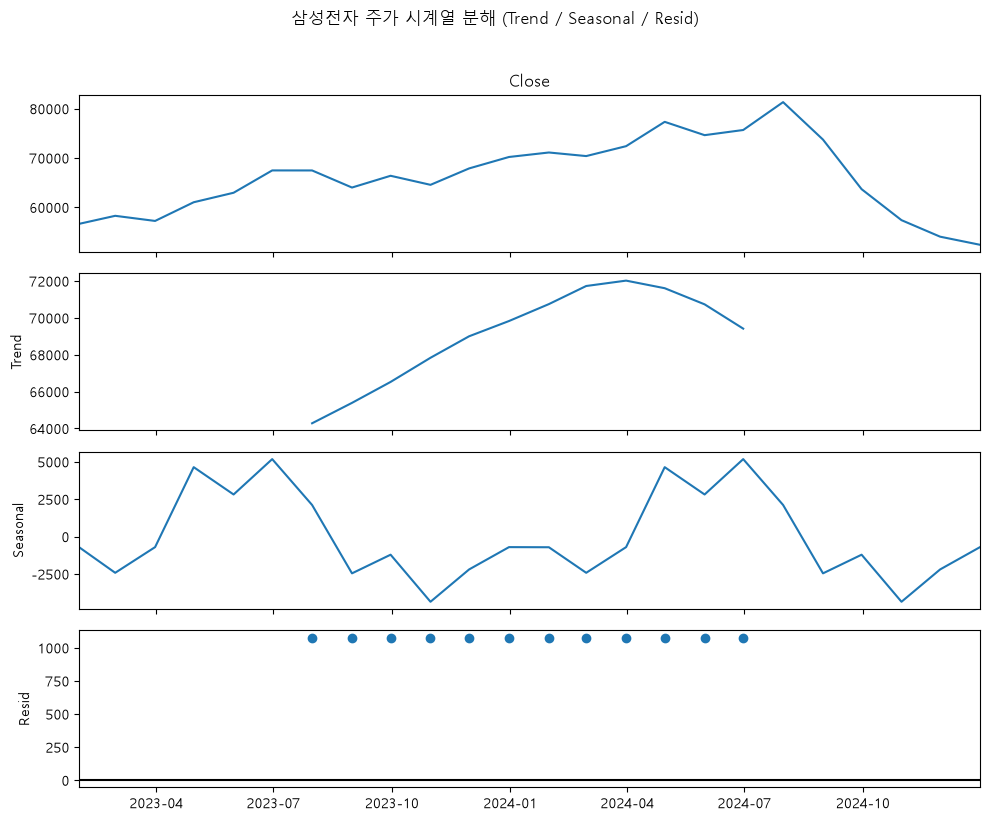

In [7]:
#보너스 과제
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. 월별 데이터를 기준으로 시계열 분해 (추세/계절성/잔차)
# Period=12는 1년(12개월) 단위의 계절성을 분석함을 의미
result = seasonal_decompose(df_monthly, model='additive', period=12)

# 2. 시각화 및 저장
fig = result.plot()
fig.set_size_inches(10, 8)
plt.suptitle('삼성전자 주가 시계열 분해 (Trend / Seasonal / Resid)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('images/04_time_series_decompose.png', dpi=300)
plt.show()

In [8]:
!pip freeze > requirements.txt